# Análise com K-Means - PIB dos Municípios Brasileiros

## 1. Importação de Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 2. Carregamento e Exploração Inicial dos Dados

In [2]:
# Carregar o dataset
df = pd.read_csv('br_ibge_pib_municipio.csv')

# Exibir as primeiras linhas
print("Primeiras linhas do dataset:")
df.head()

Primeiras linhas do dataset:


,id_municipio,ano,pib,impostos_liquidos,va,va_agropecuaria,va_industria,va_servicos,va_adespss
0,1100403,2002,45060000,3219000.0,41841000.0,9171000.0,1992000.0,8865000.0,21813000.0
1,1101005,2002,43979000,1689000.0,42290000.0,12082000.0,1718000.0,4590000.0,23899000.0
2,1200336,2002,31111000,365000.0,30746000.0,4954000.0,1462000.0,4100000.0,20230000.0
3,1200385,2002,54088000,916000.0,53172000.0,17208000.0,2609000.0,6527000.0,26827000.0
4,1301654,2002,26050000,676000.0,25374000.0,7184000.0,864000.0,2598000.0,14728000.0


In [3]:
# Informações sobre o dataset
print("\nInformações do dataset:")
df.info()


Informações do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 122466 entries, 0 to 122465
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id_municipio       122466 non-null  int64  
 1   ano                122466 non-null  int64  
 2   pib                122466 non-null  int64  
 3   impostos_liquidos  111326 non-null  float64
 4   va                 111326 non-null  float64
 5   va_agropecuaria    111326 non-null  float64
 6   va_industria       111326 non-null  float64
 7   va_servicos        111326 non-null  float64
 8   va_adespss         111326 non-null  float64
dtypes: float64(6), int64(3)
memory usage: 8.4 MB


In [4]:
# Estatísticas descritivas
print("\nEstatísticas descritivas:")
df.describe()


Estatísticas descritivas:


,id_municipio,ano,pib,impostos_liquidos,va,va_agropecuaria,va_industria,va_servicos,va_adespss
count,1.224660e+05,122466.000000,1.224660e+05,1.113260e+05,1.113260e+05,1.113260e+05,1.113260e+05,1.113260e+05,1.113260e+05
mean,3.253274e+06,2012.503830,9.307385e+08,1.194854e+08,7.155468e+08,4.016657e+07,1.738817e+08,3.817421e+08,1.197564e+08
std,9.845391e+05,6.343832,9.909266e+09,1.646866e+09,7.356382e+09,9.218991e+07,1.208217e+09,5.492226e+09,1.213122e+09
min,1.100015e+06,2002.000000,-1.904600e+07,-1.508800e+07,-5.105930e+08,-2.299000e+06,-2.897193e+09,3.720000e+05,1.447000e+06
25%,2.512101e+06,2007.000000,4.781925e+07,1.703000e+06,4.201100e+07,6.707250e+06,2.183000e+06,1.005800e+07,1.456100e+07
50%,3.146255e+06,2013.000000,1.150230e+08,5.309000e+06,9.778250e+07,1.691200e+07,7.302000e+06,2.749800e+07,2.945600e+07
75%,4.119103e+06,2018.000000,3.352805e+08,2.162750e+07,2.754320e+08,4.057250e+07,4.085025e+07,9.431575e+07,6.852600e+07
max,5.300108e+06,2023.000000,1.066825e+12,1.681840e+11,6.607967e+11,5.004239e+09,6.689305e+10,5.497675e+11,1.168092e+11


In [5]:
# Verificar valores ausentes
print("\nValores ausentes por coluna:")
df.isnull().sum()


Valores ausentes por coluna:


id_municipio             0
ano                      0
pib                      0
impostos_liquidos    11140
va                   11140
va_agropecuaria      11140
va_industria         11140
va_servicos          11140
va_adespss           11140
dtype: int64

In [6]:
# Verificar anos disponíveis no dataset
print("\nAnos disponíveis no dataset:")
print(df['ano'].unique())
print(f"\nTotal de anos: {df['ano'].nunique()}")


Anos disponíveis no dataset:
[2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015
 2016 2017 2018 2019 2020 2021 2022 2023]

Total de anos: 22


## 3. Pré-processamento dos Dados

### 3.1 Seleção de Anos para Análise

Como o dataset contém dados de múltiplos anos, selecionaremos os anos de 2023 e 2022 para a análise de clustering.

In [7]:
# Variáveis preferidas para clustering
variaveis_preferidas = ['pib', 'va_agropecuaria', 'va_industria', 'va_servicos', 'va_adespss']

# Selecionar sempre os anos de 2023 e 2022
anos_selecionados = [2023, 2022]

anos_ausentes = [ano for ano in anos_selecionados if ano not in df['ano'].values]
if anos_ausentes:
    raise ValueError(f'Os anos {anos_ausentes} não estão disponíveis no dataset.')

print(f'Anos selecionados para análise: {anos_selecionados}')

df_ano = df[df['ano'].isin(anos_selecionados)].copy()
print(f'Número de registros nos anos {anos_selecionados}: {len(df_ano)}')
print('Distribuição por ano:')
print(df_ano['ano'].value_counts().sort_index())

# Usar apenas variáveis com dados completos nos anos selecionados
variaveis_clustering = [
    var for var in variaveis_preferidas
    if var in df_ano.columns and df_ano[var].notna().all()
]

if not variaveis_clustering:
    raise ValueError('Nenhuma variável de clustering possui dados completos para 2022 e 2023.')

variaveis_indisponiveis = [var for var in variaveis_preferidas if var not in variaveis_clustering]
if variaveis_indisponiveis:
    print(f'\nVariáveis indisponíveis para {anos_selecionados}: {variaveis_indisponiveis}')
    print('O IBGE não publicou a abertura por setores para 2022/2023.')

# Quando só há PIB, reorganizar os dados por município (PIB de cada ano vira uma coluna)
if set(variaveis_clustering) == {'pib'} and len(anos_selecionados) == 2:
    df_pivot = (
        df_ano.pivot(index='id_municipio', columns='ano', values='pib')
        .dropna()
        .reset_index()
    )
    df_pivot.columns = ['id_municipio'] + [f'pib_{int(ano)}' for ano in df_pivot.columns[1:]]
    variaveis_clustering = [col for col in df_pivot.columns if col != 'id_municipio']
    df_ano = df_pivot.copy()
    print(f'\nDados reorganizados por município: {len(df_ano)} registros')
    print(f'Variáveis utilizadas no clustering: {variaveis_clustering}')
else:
    print(f'\nVariáveis utilizadas no clustering: {variaveis_clustering}')

Anos selecionados para análise: [2023, 2022]
Número de registros nos anos [2023, 2022]: 11140
Distribuição por ano:
ano
2022    5570
2023    5570
Name: count, dtype: int64

Variáveis indisponíveis para [2023, 2022]: ['va_agropecuaria', 'va_industria', 'va_servicos', 'va_adespss']
O IBGE não publicou a abertura por setores para 2022/2023.

Dados reorganizados por município: 5570 registros
Variáveis utilizadas no clustering: ['pib_2022', 'pib_2023']


### 3.2 Seleção de Variáveis para Clustering

Selecionamos as variáveis econômicas relevantes para o clustering:
- pib: Produto Interno Bruto total
- va_agropecuaria: Valor Adicionado da Agropecuária
- va_industria: Valor Adicionado da Indústria
- va_servicos: Valor Adicionado dos Serviços
- va_adespss: Valor Adicionado de ADESPSS

Para 2022 e 2023, o IBGE disponibiliza apenas o PIB total (sem abertura por setores). Nesse caso, o notebook usa automaticamente as variáveis disponíveis nesses anos.

In [8]:
df_clustering = df_ano[variaveis_clustering].copy()

print('Variáveis selecionadas para clustering:')
print(variaveis_clustering)
print(f'\nDimensões do dataframe de clustering: {df_clustering.shape}')

Variáveis selecionadas para clustering:
['pib_2022', 'pib_2023']

Dimensões do dataframe de clustering: (5570, 2)


### 3.3 Tratamento de Valores Ausentes

Verificamos e tratamos valores ausentes, se houver.

In [9]:
# Verificar o shape do dataframe antes de prosseguir
print(f"Shape de df_ano: {df_ano.shape}")
print(f"Shape de df_clustering: {df_clustering.shape}")

# Verificar se o dataframe está vazio
if df_clustering.shape[0] == 0:
    print("ERRO: O dataframe está vazio após a seleção de variáveis!")
    print("Verificando possíveis causas...")
    print(f"\nAnos disponíveis: {sorted(df['ano'].unique())}")
    print(f"Anos selecionados: {anos_selecionados}")
    print(f"Número de registros nos anos {anos_selecionados}: {len(df[df['ano'].isin(anos_selecionados)])}")
    raise ValueError(f"Não há registros para os anos {anos_selecionados}. Verifique o dataset.")
else:
    print(f"Dataframe possui {df_clustering.shape[0]} registros. Prosseguindo com a análise.")

Shape de df_ano: (5570, 3)
Shape de df_clustering: (5570, 2)
Dataframe possui 5570 registros. Prosseguindo com a análise.


In [10]:
print('Valores ausentes no dataframe de clustering:')
print(df_clustering.isnull().sum())

if df_clustering.isnull().sum().sum() > 0:
    print('\nRemovendo linhas com valores ausentes...')
    antes = len(df_clustering)
    linhas_validas = df_clustering.notna().all(axis=1)
    df_clustering = df_clustering[linhas_validas].copy()
    df_ano = df_ano.loc[df_clustering.index].copy()
    depois = len(df_clustering)
    print(f'Linhas removidas: {antes - depois}')
    print(f'Novo número de municípios: {depois}')
else:
    print('\nNão há valores ausentes no dataset.')

if df_clustering.shape[0] == 0:
    raise ValueError('O dataframe está vazio após o tratamento de valores ausentes.')

Valores ausentes no dataframe de clustering:
pib_2022    0
pib_2023    0
dtype: int64

Não há valores ausentes no dataset.


### 3.4 Normalização/Padronização dos Dados

In [11]:
# Criar o scaler
scaler = StandardScaler()

# Aplicar a padronização
df_scaled = scaler.fit_transform(df_clustering)

# Converter de volta para DataFrame para facilitar a visualização
df_scaled = pd.DataFrame(df_scaled, columns=variaveis_clustering)

print("Dados após padronização:")
df_scaled.head()

Dados após padronização:


,pib_2022,pib_2023
0,-0.056792,-0.052732
1,0.127587,0.138908
2,-0.096970,-0.095540
3,0.088421,0.108168
4,-0.057839,-0.055027


In [12]:
# Verificar estatísticas após padronização
print("Estatísticas após padronização:")
print(df_scaled.describe())

Estatísticas após padronização:
           pib_2022      pib_2023
count  5.570000e+03  5.570000e+03
mean   5.102641e-18 -5.102641e-18
std    1.000090e+00  1.000090e+00
min   -1.141181e-01 -1.113622e-01
25%   -1.076910e-01 -1.050204e-01
50%   -9.796974e-02 -9.507000e-02
75%   -6.722445e-02 -6.475818e-02
max    6.023818e+01  6.114499e+01


## 4. Implementação do Algoritmo K-Means

### 4.1 Determinação do Número Ótimo de Clusters

In [13]:
inercias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(df_scaled, kmeans.labels_))
    print(f'k={k}, Inércia: {kmeans.inertia_:.2f}, Silhouette Score: {silhouettes[-1]:.4f}')

k=2, Inércia: 3701.76, Silhouette Score: 0.9950
k=3, Inércia: 1751.92, Silhouette Score: 0.9925
k=4, Inércia: 582.53, Silhouette Score: 0.9685
k=5, Inércia: 277.78, Silhouette Score: 0.9293
k=6, Inércia: 174.76, Silhouette Score: 0.9158
k=7, Inércia: 117.18, Silhouette Score: 0.8705
k=8, Inércia: 83.27, Silhouette Score: 0.8540
k=9, Inércia: 64.51, Silhouette Score: 0.8160
k=10, Inércia: 54.41, Silhouette Score: 0.8142


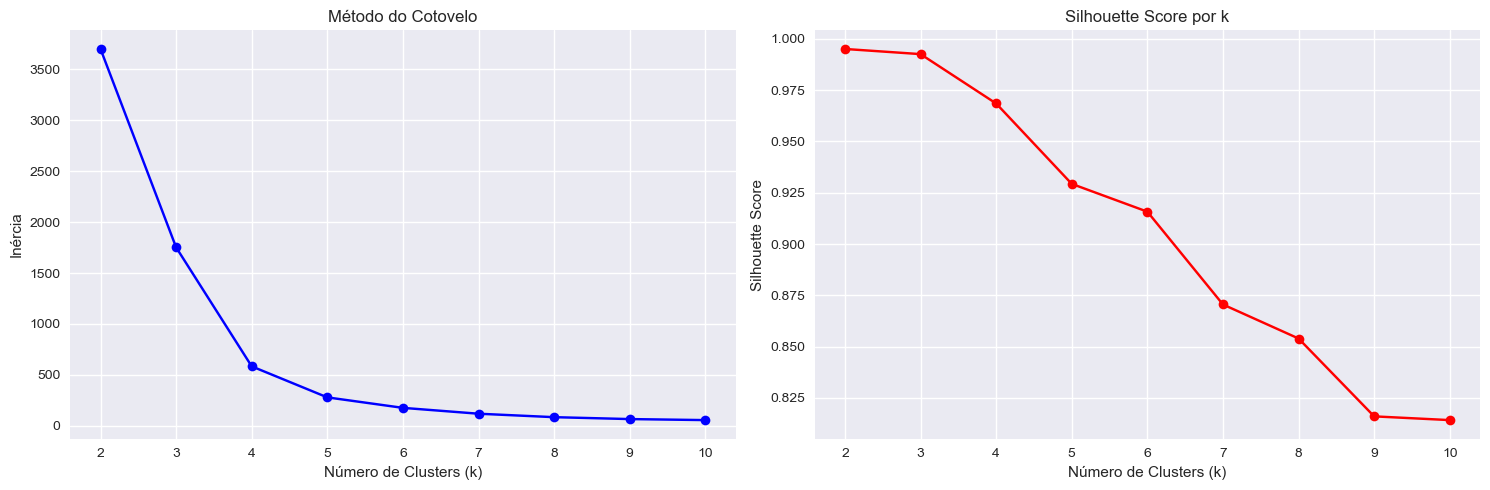

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(k_range, inercias, 'bo-')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inércia')
ax1.set_title('Método do Cotovelo')
ax1.grid(True)

ax2.plot(k_range, silhouettes, 'ro-')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score por k')
ax2.grid(True)

plt.tight_layout()
plt.show()

### 4.2 Aplicação do K-Means com k Ótimo

In [15]:
k_otimo = 4
print(f'Número de clusters selecionado: {k_otimo}')

kmeans_final = KMeans(n_clusters=k_otimo, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(df_scaled)

df_clustering = df_clustering.copy()
df_clustering['cluster'] = clusters
df_ano = df_ano.loc[df_clustering.index].copy()
df_ano['cluster'] = clusters

print('\nK-Means aplicado com sucesso!')
print(f'Inércia final: {kmeans_final.inertia_:.2f}')
print(f'Silhouette Score final: {silhouette_score(df_scaled, clusters):.4f}')

Número de clusters selecionado: 4

K-Means aplicado com sucesso!
Inércia final: 582.53
Silhouette Score final: 0.9685


### 4.3 Análise dos Clusters Formados

In [16]:
# Contagem de municípios por cluster
print("Distribuição de municípios por cluster:")
print(df_clustering['cluster'].value_counts().sort_index())

Distribuição de municípios por cluster:
cluster
0    5531
1       1
2      36
3       2
Name: count, dtype: int64


In [17]:
# Estatísticas descritivas por cluster
print("\nEstatísticas descritivas por cluster:")
for cluster in sorted(df_clustering['cluster'].unique()):
    print(f"\n--- Cluster {cluster} ---")
    print(df_clustering[df_clustering['cluster'] == cluster][variaveis_clustering].describe())


Estatísticas descritivas por cluster:

--- Cluster 0 ---
           pib_2022      pib_2023
count  5.531000e+03  5.531000e+03
mean   1.091594e+09  1.191559e+09
std    2.859426e+09  3.085918e+09
min    2.101800e+07  2.528400e+07
25%    1.212570e+08  1.351035e+08
50%    2.711870e+08  3.063640e+08
75%    7.303600e+08  8.075975e+08
max    3.147908e+10  3.407505e+10

--- Cluster 1 ---
           pib_2022      pib_2023
count  1.000000e+00  1.000000e+00
mean   9.459465e+11  1.066825e+12
std             NaN           NaN
min    9.459465e+11  1.066825e+12
25%    9.459465e+11  1.066825e+12
50%    9.459465e+11  1.066825e+12
75%    9.459465e+11  1.066825e+12
max    9.459465e+11  1.066825e+12

--- Cluster 2 ---
           pib_2022      pib_2023
count  3.600000e+01  3.600000e+01
mean   6.630421e+10  6.949661e+10
std    2.871682e+10  2.904200e+10
min    3.415388e+10  3.693135e+10
25%    4.478230e+10  4.490719e+10
50%    6.195734e+10  6.505976e+10
75%    8.082553e+10  7.925904e+10
max    1.583943e+11 

In [18]:
# Médias por cluster
medias_cluster = df_clustering.groupby('cluster')[variaveis_clustering].mean()
print("Médias das variáveis por cluster:")
print(medias_cluster)

Médias das variáveis por cluster:
             pib_2022      pib_2023
cluster                            
0        1.091594e+09  1.191559e+09
1        9.459465e+11  1.066825e+12
2        6.630421e+10  6.949661e+10
3        3.545855e+11  3.920657e+11


## 5. Visualização dos Resultados

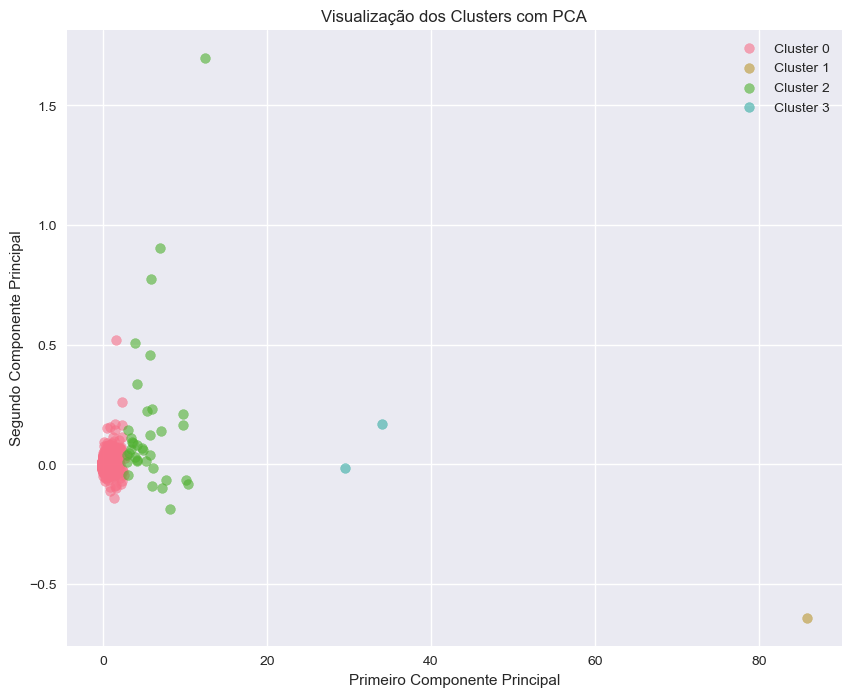

In [19]:
from sklearn.decomposition import PCA

# Aplicar PCA para reduzir para 2 dimensões (ou 1, se houver apenas uma variável)
n_componentes = min(2, df_scaled.shape[1])
pca = PCA(n_components=n_componentes)
df_pca = pca.fit_transform(df_scaled)

colunas_pca = [f'PC{i + 1}' for i in range(n_componentes)]
df_pca = pd.DataFrame(df_pca, columns=colunas_pca)
df_pca['cluster'] = clusters

# Plotar os clusters
plt.figure(figsize=(10, 8))
if n_componentes == 2:
    for cluster in sorted(df_pca['cluster'].unique()):
        plt.scatter(df_pca[df_pca['cluster'] == cluster]['PC1'],
                    df_pca[df_pca['cluster'] == cluster]['PC2'],
                    label=f'Cluster {cluster}', alpha=0.6, s=50)
    plt.xlabel('Primeiro Componente Principal')
    plt.ylabel('Segundo Componente Principal')
    plt.title('Visualização dos Clusters com PCA')
else:
    for cluster in sorted(df_pca['cluster'].unique()):
        plt.scatter(df_pca[df_pca['cluster'] == cluster]['PC1'],
                    np.zeros(len(df_pca[df_pca['cluster'] == cluster])),
                    label=f'Cluster {cluster}', alpha=0.6, s=50)
    plt.xlabel('Primeiro Componente Principal')
    plt.yticks([])
    plt.title('Visualização dos Clusters com PCA (1 componente)')

plt.legend()
plt.grid(True)
plt.show()

### 5.1 Boxplots por Cluster

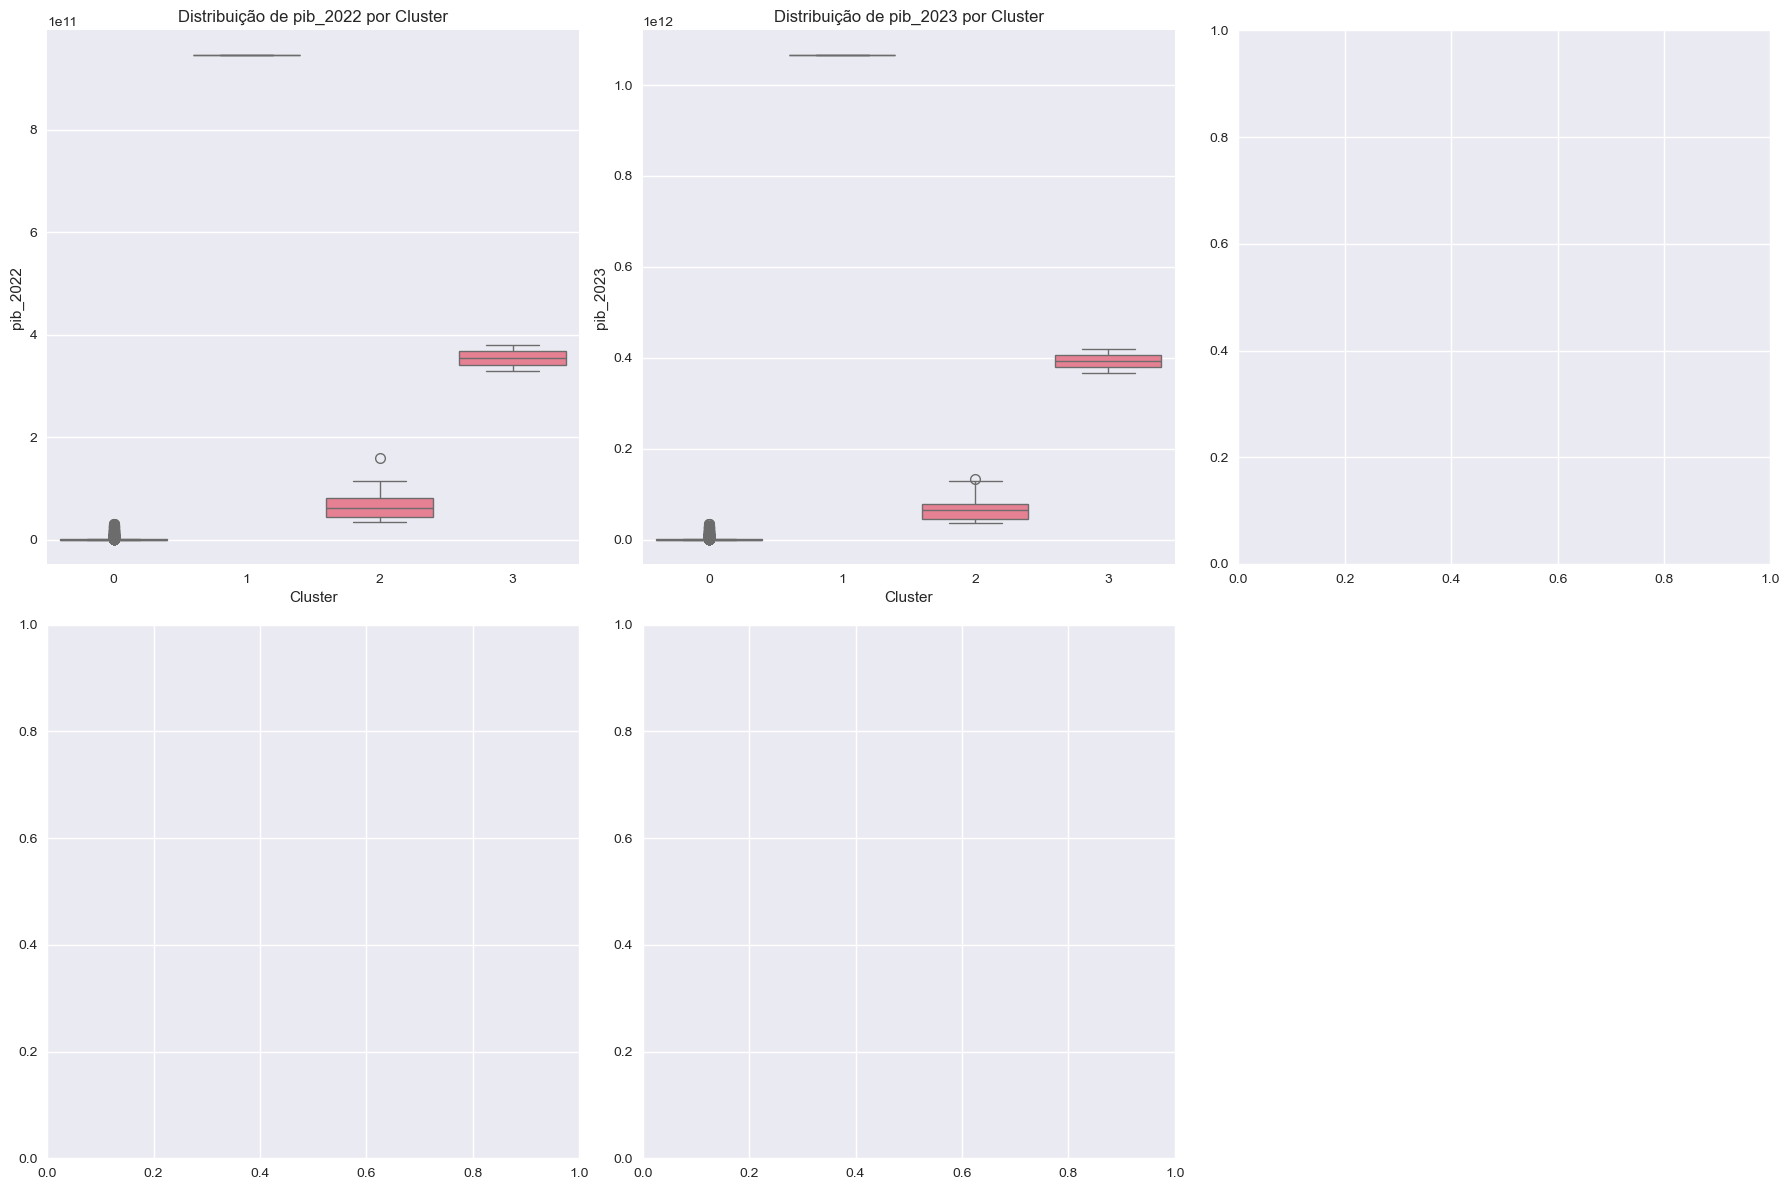

In [20]:
# Criar boxplots para cada variável
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(variaveis_clustering):
    sns.boxplot(data=df_clustering, x='cluster', y=var, ax=axes[i])
    axes[i].set_title(f'Distribuição de {var} por Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(var)

# Remover o último subplot vazio
axes[-1].remove()

plt.tight_layout()
plt.show()

### 5.3 Heatmap das Médias por Cluster

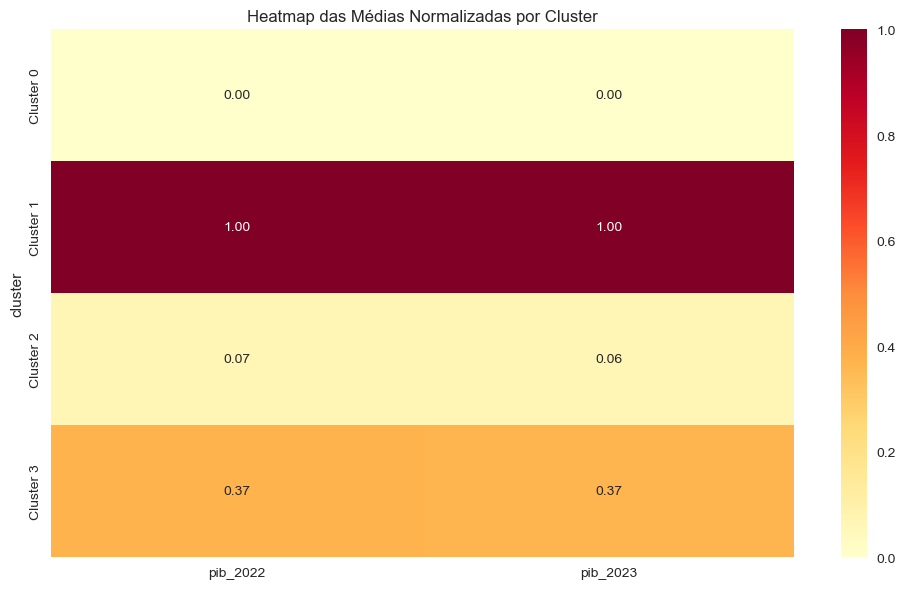

In [21]:
# Normalizar as médias para melhor visualização no heatmap
medias_cluster_norm = (medias_cluster - medias_cluster.min()) / (medias_cluster.max() - medias_cluster.min())

# Criar heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(medias_cluster_norm, annot=True, cmap='YlOrRd', fmt='.2f',
            xticklabels=variaveis_clustering, yticklabels=[f'Cluster {i}' for i in range(k_otimo)])
plt.title('Heatmap das Médias Normalizadas por Cluster')
plt.tight_layout()
plt.show()

## 6. Interpretação dos Clusters

Com base nas análises realizadas, podemos interpretar os clusters formados:

In [22]:
# Exibir interpretação dos clusters
print("Interpretação dos Clusters:")
print("=" * 50)

for cluster in sorted(medias_cluster.index):
    print(f"\nCluster {cluster}:")
    print(f"  - Número de municípios: {len(df_clustering[df_clustering['cluster'] == cluster])}")
    for var in variaveis_clustering:
        print(f"  - {var} médio: R$ {medias_cluster.loc[cluster, var]:,.2f}")

Interpretação dos Clusters:

Cluster 0:
  - Número de municípios: 5531
  - pib_2022 médio: R$ 1,091,594,144.82
  - pib_2023 médio: R$ 1,191,558,675.47

Cluster 1:
  - Número de municípios: 1
  - pib_2022 médio: R$ 945,946,483,000.00
  - pib_2023 médio: R$ 1,066,825,105,000.00

Cluster 2:
  - Número de municípios: 36
  - pib_2022 médio: R$ 66,304,211,138.89
  - pib_2023 médio: R$ 69,496,605,861.11

Cluster 3:
  - Número de municípios: 2
  - pib_2022 médio: R$ 354,585,539,000.00
  - pib_2023 médio: R$ 392,065,734,000.00
